# 03 — Phase 2: the clock, and actually looking at it

*C23–C27. Written after the Phase 2 results were challenged as summary statistics with no shape behind them.*

Companion to `bitacora/06_phase2_clock.md`.

In [1]:
"""Path setup: makes the notebook runnable from anywhere."""
import os, sys, json, warnings
warnings.filterwarnings("ignore")

here = os.path.abspath(os.getcwd())
while here != "/" and not os.path.exists(os.path.join(here, "PROTOCOL_causal_timeseries.md")):
    here = os.path.dirname(here)
if here == "/":
    here = os.path.expanduser("~/Documents/projects/CausalBool/imp-prices")
ROOT = here
sys.path.insert(0, os.path.join(ROOT, "src"))
sys.path.insert(0, os.path.join(ROOT, "scripts"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})
print("root:", ROOT)
print("numpy", np.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

root: /Users/alberto/Documents/projects/CausalBool/imp-prices
numpy 2.2.6 | pandas 2.3.3 | matplotlib 3.11.1


## 1. Why this notebook exists

Phase 2 was reported with no figures at all: a mean excess of +0.129, a sign
test, some base rates and lag statistics. The assessor's objection was that this
is **Datasaurus syndrome** — summary statistics that could sit on any number of
different shapes, none of which had been looked at.

The objection was right, and acting on it changed what should be reported,
though not the verdict. This notebook does the looking.

### 2. Do the pivots land on real events, or on nothing?

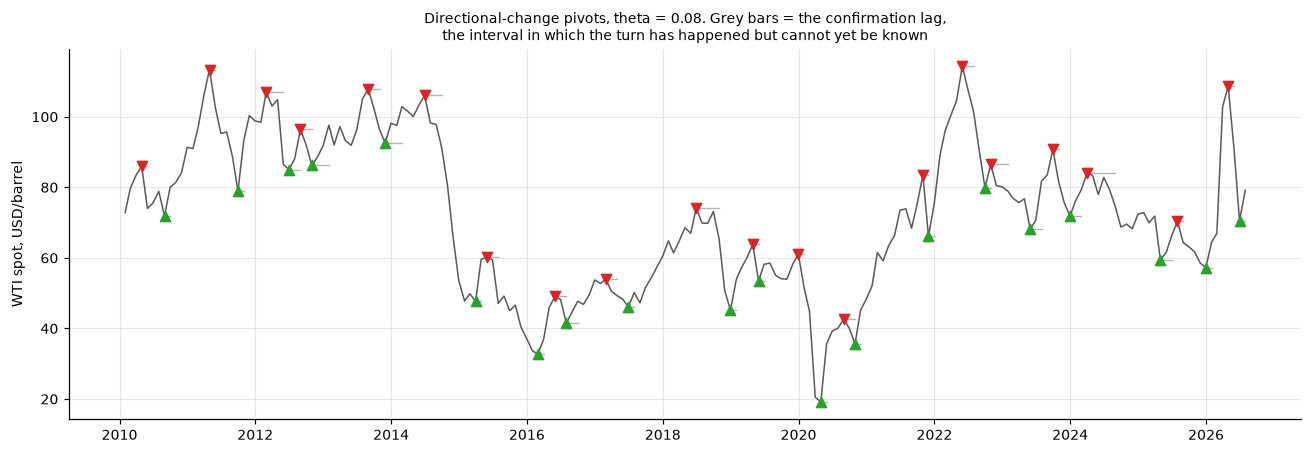

The first twenty turning points, with the date they could first be known:
   2010-04-30  peak      86.07   knowable 2010-05-31  (lag 1)
   2010-08-31  trough    71.93   knowable 2010-09-30  (lag 1)
   2011-04-30  peak     113.39   knowable 2011-05-31  (lag 1)
   2011-09-30  trough    78.93   knowable 2011-10-31  (lag 1)
   2012-02-29  peak     107.08   knowable 2012-05-31  (lag 3)
   2012-06-30  trough    85.04   knowable 2012-08-31  (lag 2)
   2012-08-31  peak      96.47   knowable 2012-10-31  (lag 2)
   2012-10-31  trough    86.23   knowable 2013-01-31  (lag 3)
   2013-08-31  peak     107.98   knowable 2013-10-31  (lag 2)
   2013-11-30  trough    92.55   knowable 2014-02-28  (lag 3)
   2014-06-30  peak     106.07   knowable 2014-09-30  (lag 3)
   2015-03-31  trough    47.72   knowable 2015-04-30  (lag 1)
   2015-05-31  peak      60.25   knowable 2015-07-31  (lag 2)
   2016-02-29  trough    32.74   knowable 2016-03-31  (lag 1)
   2016-05-31  peak      49.10   knowable 2016-07-31  (lag

In [2]:
from imp_prices import load_panel, TARGET
from imp_prices.pivots import directional_change, legs, short_wait_target, leak_opportunities

panel = load_panel(); px = panel[TARGET]; p = px.to_numpy(); idx = px.index
pv = directional_change(p, 0.08)

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(idx, p, color="0.35", lw=1.0)
for q in pv:
    ax.scatter(idx[q.extreme_index], q.extreme_price, s=44, zorder=3,
               color="#D62728" if q.kind == "peak" else "#2CA02C",
               marker="v" if q.kind == "peak" else "^")
    ax.plot([idx[q.extreme_index], idx[q.confirm_index]],
            [q.extreme_price, q.extreme_price], color="0.7", lw=0.9, zorder=2)
ax.set_ylabel("WTI spot, USD/barrel")
ax.set_title("Directional-change pivots, theta = 0.08. Grey bars = the confirmation lag,\n"
             "the interval in which the turn has happened but cannot yet be known", fontsize=9)
plt.tight_layout(); plt.show()

print("The first twenty turning points, with the date they could first be known:")
for q in pv[:20]:
    print(f"   {idx[q.extreme_index].date()}  {q.kind:<7s} {q.extreme_price:7.2f}"
          f"   knowable {idx[q.confirm_index].date()}  (lag {q.lag})")

These are the real turning points: the 2011 Arab Spring peak at 113.39, the June
2014 peak at 106.07 that begins the shale collapse, the February 2016 bottom at
32.74, the December 2018 trough at 45.15. The encoding is not manufacturing
events; it is finding the ones an energy analyst would name.

### 3. How big is the leak window? (C23)

,n_pivots,n_times_with_leak,fraction_of_time,mean_lag,max_lag,min_lag
theta,,,,,,
0.05,58,74,0.3719,1.276,3,1
0.08,40,69,0.3467,1.725,5,1
0.10,38,76,0.3819,2.000,7,1
0.15,29,90,0.4523,3.103,13,1
0.20,19,76,0.3819,4.000,14,1
0.25,15,79,0.3970,5.267,19,1


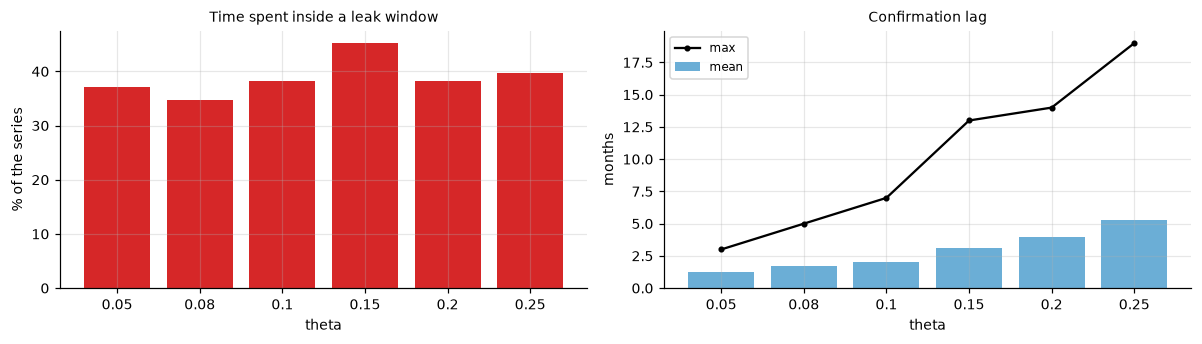

A third to a half of the sample sits in a window where a pivot has occurred
but is not yet knowable. A naive implementation would not be slightly
contaminated; it would be contaminated most of the time.


In [3]:
rows = []
for th in (0.05, 0.08, 0.10, 0.15, 0.20, 0.25):
    q = directional_change(p, th)
    rows.append(dict(theta=th, **leak_opportunities(q, len(p))))
lk = pd.DataFrame(rows).set_index("theta")
display(lk)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].bar(lk.index.astype(str), 100 * lk["fraction_of_time"], color="#D62728")
axes[0].set_ylabel("% of the series"); axes[0].set_xlabel("theta")
axes[0].set_title("Time spent inside a leak window", fontsize=9)
axes[1].bar(lk.index.astype(str), lk["mean_lag"], color="#6BAED6", label="mean")
axes[1].plot(lk.index.astype(str), lk["max_lag"], "k.-", label="max")
axes[1].set_ylabel("months"); axes[1].set_xlabel("theta"); axes[1].legend(fontsize=8)
axes[1].set_title("Confirmation lag", fontsize=9)
plt.tight_layout(); plt.show()
print("A third to a half of the sample sits in a window where a pivot has occurred")
print("but is not yet knowable. A naive implementation would not be slightly")
print("contaminated; it would be contaminated most of the time.")

### 4. What does the clock actually look like? (C24)

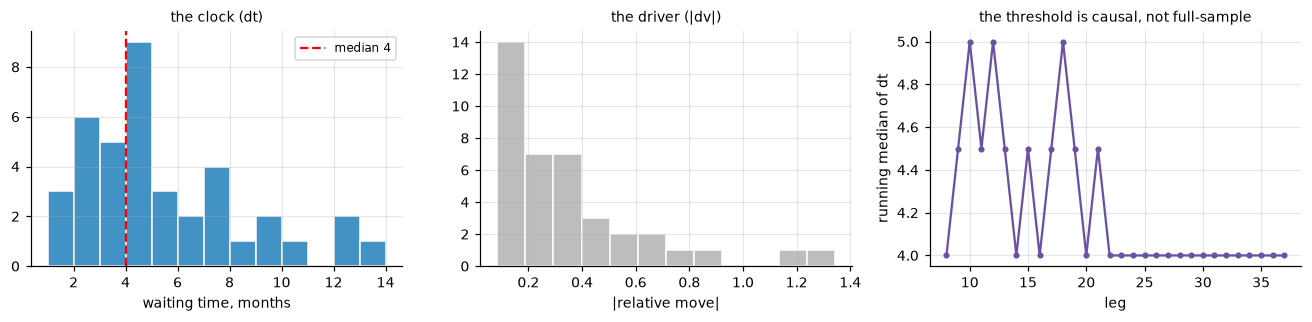

short-wait base rate: 0.467  <- near balanced BY CONSTRUCTION
Compare the regime target: 66 to 73 per cent stagnant (A7, A11), which is why
GWP3's 75.9 per cent accuracy was indistinguishable from persistence.


In [4]:
lg = legs(pv); tgt = short_wait_target(lg)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.0))
axes[0].hist(lg["dt"], bins=range(1, int(lg["dt"].max()) + 2), color="#4292C6",
             edgecolor="white")
axes[0].axvline(lg["dt"].median(), color="red", ls="--", label=f"median {lg['dt'].median():.0f}")
axes[0].set_xlabel("waiting time, months"); axes[0].legend(fontsize=8)
axes[0].set_title("the clock (dt)", fontsize=9)
axes[1].hist(np.abs(lg["dv"]), bins=12, color="#BDBDBD", edgecolor="white")
axes[1].set_xlabel("|relative move|"); axes[1].set_title("the driver (|dv|)", fontsize=9)
axes[2].plot(tgt["leg"], tgt["running_median"], "o-", ms=3, color="#6A51A3")
axes[2].set_xlabel("leg"); axes[2].set_ylabel("running median of dt")
axes[2].set_title("the threshold is causal, not full-sample", fontsize=9)
plt.tight_layout(); plt.show()
print(f"short-wait base rate: {tgt['short'].mean():.3f}  <- near balanced BY CONSTRUCTION")
print("Compare the regime target: 66 to 73 per cent stagnant (A7, A11), which is why")
print("GWP3's 75.9 per cent accuracy was indistinguishable from persistence.")

### 5. The Datasaurus check: what shape is the null?

The reported statistic was `null_edge_mean ± sd`. With a test set of twelve, the
accuracy can take only thirteen values, so summarising the null by a mean and a
standard deviation may be describing something that has no business being
described that way. Here is the distribution itself.

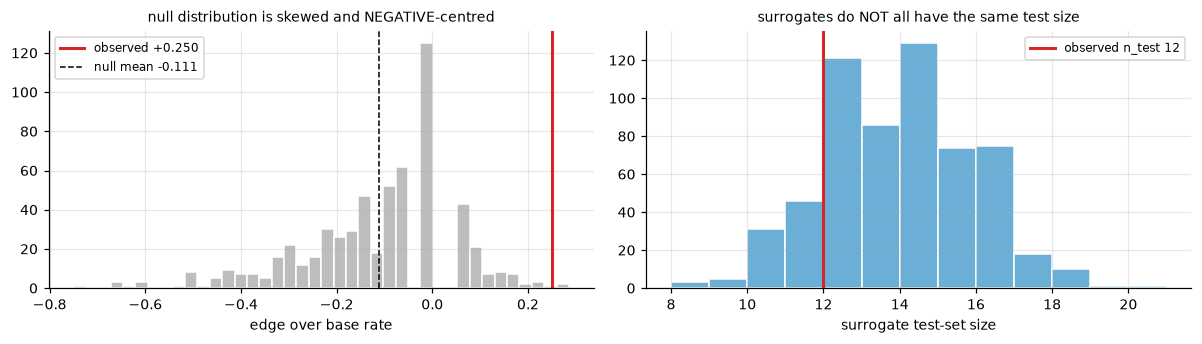

observed edge +0.2500 = 3 extra correct calls out of 12
null mean -0.1111, sd 0.1623, skew -0.734
surrogate n_test: median 14, range 8-20, matching observed in 20.2% of cases


In [5]:
from imp_prices.clock import clock_forecast, return_shuffle
obs = clock_forecast(p, 0.08); oe = obs["accuracy"] - obs["base_rate"]
rng = np.random.default_rng(42)
rows = []
for _ in range(600):
    s = clock_forecast(return_shuffle(p, rng), 0.08)
    if s: rows.append((s["n_test"], s["accuracy"] - s["base_rate"]))
ns = np.array([r[0] for r in rows]); es = np.array([r[1] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(es, bins=40, color="#BDBDBD", edgecolor="white")
axes[0].axvline(oe, color="#D62728", lw=2, label=f"observed {oe:+.3f}")
axes[0].axvline(es.mean(), color="black", ls="--", lw=1, label=f"null mean {es.mean():+.3f}")
axes[0].set_xlabel("edge over base rate"); axes[0].legend(fontsize=8)
axes[0].set_title("null distribution is skewed and NEGATIVE-centred", fontsize=9)
axes[1].hist(ns, bins=range(ns.min(), ns.max() + 2), color="#6BAED6", edgecolor="white")
axes[1].axvline(obs["n_test"], color="#D62728", lw=2, label=f"observed n_test {obs['n_test']}")
axes[1].set_xlabel("surrogate test-set size"); axes[1].legend(fontsize=8)
axes[1].set_title("surrogates do NOT all have the same test size", fontsize=9)
plt.tight_layout(); plt.show()

print(f"observed edge {oe:+.4f} = {oe*obs['n_test']:.0f} extra correct calls out of {obs['n_test']}")
print(f"null mean {es.mean():+.4f}, sd {es.std():.4f}, skew "
      f"{float(((es-es.mean())**3).mean()/es.std()**3):+.3f}")
print(f"surrogate n_test: median {int(np.median(ns))}, range {ns.min()}-{ns.max()}, "
      f"matching observed in {(ns==obs['n_test']).mean():.1%} of cases")

#### Why the null is centred below zero, and what that does to the headline

It is not noise. A lookup table fitted on a random prefix scores about 0.5 on the
test suffix, while the base rate — the larger of the two class shares — is
necessarily at least 0.5 and here about 0.58. So a *correctly specified* null
model scores about −0.11. That is an **overfitting penalty**, and it is real.

The consequence for reporting is that the headline "mean excess +0.129" adds a
modest observed edge of about +0.096 to the null's penalty of about −0.115 and
presents the sum as one number. That is exactly the aggregate the Datasaurus
objection warns about: it flatters, and it conceals that the effect rests on a
single cell.

In [6]:
m = ns == obs["n_test"]
print("Is the result an artefact of the test-size mismatch? Condition on it:")
for th in (0.05, 0.08, 0.10):
    o = clock_forecast(p, th); e = o["accuracy"] - o["base_rate"]
    r2 = np.random.default_rng(42); rr = []
    for _ in range(600):
        s = clock_forecast(return_shuffle(p, r2), th)
        if s: rr.append((s["n_test"], s["accuracy"] - s["base_rate"]))
    n2 = np.array([x[0] for x in rr]); e2 = np.array([x[1] for x in rr])
    mm = n2 == o["n_test"]
    p_all = (np.sum(e2 >= e) + 1) / (len(e2) + 1)
    p_mat = (np.sum(e2[mm] >= e) + 1) / (mm.sum() + 1)
    print(f"  theta {th}: obs {e:+.4f} | p(all surrogates) {p_all:.4f} | "
          f"p(matched n_test, n={mm.sum()}) {p_mat:.4f}")
print("\nThe rank-based p-values are robust to the mismatch. The MEAN was the")
print("misleading statistic, not the test.")

Is the result an artefact of the test-size mismatch? Condition on it:


  theta 0.05: obs -0.0526 | p(all surrogates) 0.4393 | p(matched n_test, n=51) 0.4423


  theta 0.08: obs +0.2500 | p(all surrogates) 0.0050 | p(matched n_test, n=121) 0.0082


  theta 0.1: obs +0.0909 | p(all surrogates) 0.1433 | p(matched n_test, n=90) 0.1319

The rank-based p-values are robust to the mismatch. The MEAN was the
misleading statistic, not the test.


### 6. What survives the looking

**Unchanged.** B6 is not supported. The honest summary is not a mean excess but a
count: **one cell of nine** reaches significance (θ = 0.08, matched-null
*p* = 0.008), and with nine cells a Bonferroni correction puts it at 0.074. The
sign is consistently positive — ten of twelve cells across both frequencies — and
the sample cannot establish it.

**Corrected.** The headline "mean excess +0.129" is demoted. It sums a real edge
of about +0.096 with the null's overfitting penalty of about −0.115 and reports
the total as though it were one effect. The rank-based *p*-values, which are what
the verdict actually rested on, survive conditioning on test-set size.

**A suspicion of mine that did not survive.** I expected volatility clustering to
give the real series systematically fewer pivots than its shuffle, which would
have made the null unmatched on leg count. It does not, at this resolution:
z = −1.07, −0.73 and +0.38 across the three thresholds. The concern was
reasonable and it was wrong.

**What the looking confirmed.** The pivots are economically real — the 2014 peak,
the 2016 bottom, the 2018 trough — so the encoding is sound and the negative is
about the sample, not about the representation.